In [69]:
%load_ext autoreload
%autoreload 2
# Always Restart Kernel after modifying backend file
from backend_aipw import *
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from sklearn.linear_model import Lasso, ElasticNet, LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, GridSearchCV
from catboost import CatBoostRegressor
from scipy.special import logit, expit
import matplotlib.pyplot as plt
#from celer import FusedLasso

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
def dgp1(rng, n):
    n_groups = 6       # e.g. (Low/Mid/High) × (Male/Female)
    # no sparsity

    X, _ = make_group_design(n, rng, n_groups)

    beta0 = rng.uniform(0.5, 1.5, size=n_groups)
    beta1 = beta0 + 1.0

    eps0 = rng.normal(0, 1, size=n)
    eps1 = rng.normal(0, 1, size=n)

    Y0 = X @ beta0 + eps0
    Y1 = X @ beta1 + eps1

    D = rng.binomial(1, 0.5, size=n)
    Y = D * Y1 + (1 - D) * Y0

    return X, D, Y, 1.0

In [71]:
def dgp2(rng, n):
    n_groups = int(0.1 * n)
    s_unique = 5       # strong group sparsity

    X, _ = make_group_design(n, rng, n_groups)

    beta0 = make_group_sparse_beta(n_groups, s_unique, rng)
    beta1 = beta0 + 1.0

    eps0 = rng.normal(0, 1, size=n)
    eps1 = rng.normal(0, 1, size=n)

    Y0 = X @ beta0 + eps0
    Y1 = X @ beta1 + eps1

    D = rng.binomial(1, 0.5, size=n)
    Y = D * Y1 + (1 - D) * Y0

    return X, D, Y, 1.0

In [72]:
def dgp3_anomaly(rng, n):
    n_groups = int(2.5 * n)
    s_unique = n_groups  # no sparsity at all

    X, _ = make_group_design(n, rng, n_groups)

    beta0 = rng.uniform(0.5, 1.5, size=n_groups)
    beta1 = beta0 + 1.0

    eps0 = rng.normal(0, 1, size=n)
    eps1 = rng.normal(0, 1, size=n)

    Y0 = X @ beta0 + eps0
    Y1 = X @ beta1 + eps1

    D = rng.binomial(1, 0.5, size=n)
    Y = D * Y1 + (1 - D) * Y0

    return X, D, Y, 1.0

In [73]:
def generate_dgp3_params(rng, n, dim_factor, spars_factor): # Takes as input the sample size, dimensionality factor, and sparsity factor
    # Hyperparameters controlling the strength of confounding and noise
    p_band = [0.2, 0.8]
    beta_strength = 2.5 # Before 3.0
    rho_strength = 0.8 # Before 1.2
    beta_noise = 0.5
    rho_noise = 0.3
    
    # Set Dimensionality
    n_groups = int(dim_factor * n)  # Dimensionality: grows with n
    
    # Set Sparsity
    nunique = int(spars_factor * n_groups) # Signal Sparsity: varies with n
    #nunique = 5 # Fixed Sparsity
    
    s_unique = rng.normal(0, 1, nunique)
    s = np.resize(s_unique, n_groups)

    # Baseline outcomes (beta_g) are driven by latent 's'
    beta_g = beta_strength * s + beta_noise * rng.normal(0, 1, size=n_groups)
    # Propensity latent score (rho_latent) is ALSO driven by 's' -> Strong Confounding!
    rho_latent = rho_strength * s + rho_noise * rng.normal(0, 1, size=n_groups)

    # Bound Propensities cleanly strictly within p_band
    a = logit(p_band[0])
    b = logit(p_band[1])
    rho_g = np.clip(rho_latent, a, b)
    p_g = expit(rho_g) # convert back to probabilities

    return n_groups, beta_g, p_g

In [74]:
# --- New Supervisor-Inspired DGP 3 ---
def dgp3_supervisor(rng, n, n_groups, beta_g, p_g):
    """
    High-dimensional, strongly confounded DGP based on supervisor's R code.
    Breaks AIPW by combining sparsity with extreme correlation between 
    outcomes and propensity scores.
    """
    # Generate the Sample
    gid = rng.integers(0, n_groups, size=n)
    
    # One-hot encoding matrix
    X = np.zeros((n, n_groups))
    X[np.arange(n), gid] = 1.0

    # Map group parameters to individuals
    mu0 = beta_g[gid]
    mu1 = mu0 + 1.0  # Constant treatment effect tau = 1.0
    p = p_g[gid]

    # Assign treatment based on confounded propensity
    D = rng.binomial(1, p)

    # Generate Final Outcomes
    sigma_y = 1.0
    Y0 = mu0 + rng.normal(0, sigma_y, size=n)
    Y1 = mu1 + rng.normal(0, sigma_y, size=n)
    Y = D * Y1 + (1 - D) * Y0

    return X, D, Y, 1.0

In [75]:
"""
Plan - Used Machine Learners
1) OLS
1) Ridge
2) Lasso
3) Elastic Net
4) Random Forest
5) Gradient Boosting
6) CatBoost
7) Fused Lasso
8) XGBoost
9) Conditional Inference Forest
10) Logit Lasso
"""


learners_regime = {
    # Worst Estimator to Best Estimator
    "OLS": LinearRegression(),
    "Lasso": Lasso(max_iter=5000),
    "ElasticNet": ElasticNet(max_iter=5000),
    "RF": RandomForestRegressor(n_estimators=300, random_state=123, n_jobs=1),
    "GB": GradientBoostingRegressor(n_estimators=300, random_state=123),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=123, iterations=300),
}

In [ ]:
## DGP 1
#print("DGP 1")
#tuned_learners_1 = tune_once(dgp1, learners_regime, n=100)
#print(monte_carlo(dgp1, tuned_learners_1, n=100, sims=100))
#
## DGP 2
#print("DGP 2")
#tuned_learners_2 = tune_once(dgp2, learners_regime, n=100)
#print(monte_carlo(dgp2, tuned_learners_2, n=100, sims=100))

# DGP 3
# MC Parameters 
n = 100 # Sample size
dim_factor = 0.3 # Dimensionality factor: when dim_factor > 1.0 the number of groups exceeds the sample size, creating a high-dimensional setting 
spars_factor = 0.5 # Sparsity factor: when spars_factor = 1.0, there is no sparsity

print("DGP 3")
print("Sample Size", n)
print("Dimensionality", dim_factor)
print("Sparsity", spars_factor)
n_groups, beta_g, p_g = generate_dgp3_params(np.random.default_rng(0), n=n, dim_factor=dim_factor, spars_factor=spars_factor) # Generate parameters once for consistency across Monte Carlo
tuned_learners_3 = tune_once_parallel(dgp3_supervisor, learners_regime, n=100, n_groups=n_groups, beta_g=beta_g, p_g=p_g) # Tune parameters once 
print(monte_carlo_parallel(dgp3_supervisor, tuned_learners_3, n=100, sims=100, n_groups=n_groups, beta_g=beta_g, p_g=p_g))

DGP 3
Sample Size 100
Dimensionality 0.3
Sparsity 0.5


In [77]:
# ANALYSIS - Dimensionality
dimensionality_sizes = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]  # Factors of n to determine number of groups
fixed_sample_size = 200
fixed_sparsity_size = 0.5
results_n = []

for dim in dimensionality_sizes:
    print(f"Running simulation for n={dim}...")
    # Define learner regime (Tuned or using robust defaults)
    # Run Monte Carlo for this specific n
    # Note: dgp3_supervisor should use n_groups = int(0.8 * n) internally
    tuned_learners = tune_once(dgp3_supervisor, learners_regime, n=200, factor_groups = dim)
    batch_results = monte_carlo(dgp3_supervisor, tuned_learners, n=200, sims=200, factor_groups = dim)
    batch_results['n'] = dim
    results_n.append(batch_results.reset_index())

# Process and Plot
df_n = pd.concat(results_n)
plt.figure(figsize=(10, 6))
for learner in df_n['Learner'].unique():
    subset = df_n[df_n['Learner'] == learner]
    plt.plot(subset['n'], subset['Coverage'], marker='o', label=learner)

plt.axhline(y=0.95, color='r', linestyle='--', label='Target Coverage')
plt.title("Coverage vs Dimensionality (Constant sample size = 200, Constant signal sparsity = 1.0, Number of simulations = 200)")
plt.xlabel("Dimensionality")
plt.ylabel("Coverage Ratio")
plt.legend()
plt.grid(True)
plt.show()

Running simulation for n=0.1...


TypeError: tune_once() got an unexpected keyword argument 'factor_groups'

Running simulation for n=200 (Fixed p/n ratio=0.8)...
Running simulation for n=400 (Fixed p/n ratio=0.8)...
Running simulation for n=600 (Fixed p/n ratio=0.8)...
Running simulation for n=800 (Fixed p/n ratio=0.8)...
Running simulation for n=1000 (Fixed p/n ratio=0.8)...


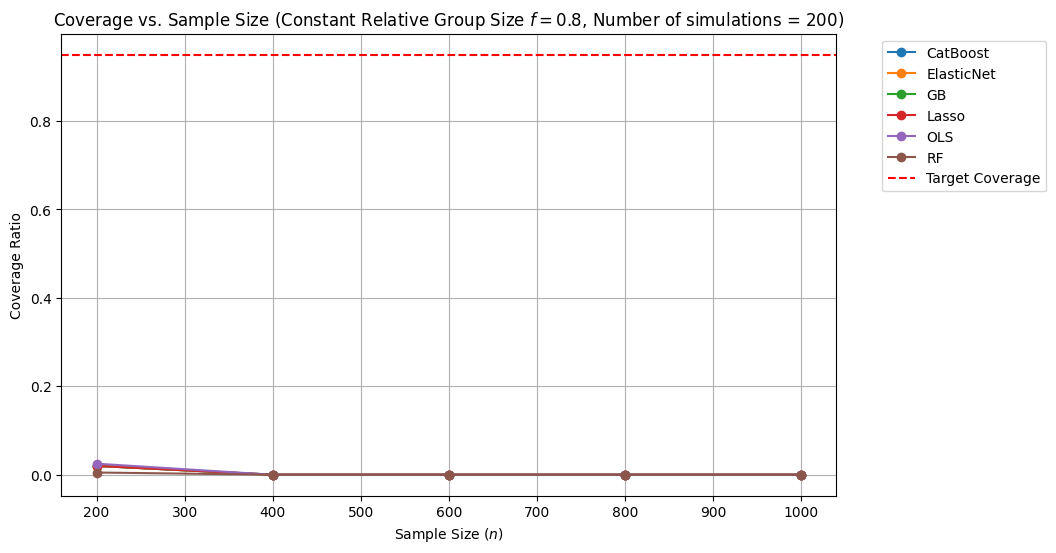

In [ ]:
# ANALYSIS - Sparsity
sample_sizes = [200, 400, 600, 800, 1000] 
# 2. Fix the Sparsity Ratio (e.g., 0.8 means p is always 80% of n)
fixed_f = 0.15

results_size = []

for n_val in sample_sizes:
    print(f"Running simulation for n={n_val} (Fixed p/n ratio={fixed_f})...")
    
    # We tune on the specific sample size to account for changing n
    tuned_learners = tune_once(dgp3_supervisor, learners_regime, n=n_val, factor_groups=fixed_f)
    
    # Run Monte Carlo
    # High sims (250) ensures the lines are smooth and not 'jagged'
    batch_results = monte_carlo(dgp3_supervisor, tuned_learners, n=n_val, sims=200, factor_groups=fixed_f)
    
    batch_results['sample_size'] = n_val
    results_size.append(batch_results.reset_index())

# Process and Plot
df_size = pd.concat(results_size)
plt.figure(figsize=(10, 6))

for learner in df_size['Learner'].unique():
    # Corrected plotting line:
    subset = df_size[df_size['Learner'] == learner]
    plt.plot(subset['sample_size'], subset['Coverage'], marker='o', label=learner)

plt.axhline(y=0.95, color='r', linestyle='--', label='Target Coverage')
plt.title(f"Coverage vs. Sample Size (Constant Relative Group Size $f={fixed_f}$, Number of simulations = 200)")
plt.xlabel("Sample Size ($n$)")
plt.ylabel("Coverage Ratio")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()




In [ ]:
# ANALYSIS - Sample Size